In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA_DIR = "/content/drive/MyDrive/Prototyping/final_dataset"

In [ ]:
!pip install pycocotools

In [ ]:
import torch
import torchvision
from pycocotools.coco import COCO
import numpy as np
import cv2
import os

class BananaDataset(torch.utils.data.Dataset):
    def __init__(self, root, annFile):
        self.root = root
        self.coco = COCO(annFile)
        self.ids = list(self.coco.imgs.keys())

    def __getitem__(self, idx):
        coco = self.coco
        img_id = self.ids[idx]
        ann_ids = coco.getAnnIds(imgIds=img_id)
        anns = coco.loadAnns(ann_ids)

        path = coco.loadImgs(img_id)[0]['file_name']

        full_path = os.path.join(self.root, path)
        print("Trying to load:", full_path)



        boxes = []
        masks = []
        labels = []

        img = cv2.imread(full_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        anns = anns[:50]

        for ann in anns:
            xmin, ymin, w, h = ann['bbox']

            # Convert to float (fix)
            xmin, ymin, w, h = float(xmin), float(ymin), float(w), float(h)

            boxes.append([xmin, ymin, xmin + w, ymin + h])
            labels.append(1)

            mask = coco.annToMask(ann)
            masks.append(mask)

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        masks = torch.as_tensor(np.array(masks), dtype=torch.uint8)

        target = {
            "boxes": boxes,
            "labels": labels,
            "masks": masks
        }

        img = torchvision.transforms.functional.to_tensor(img)
        if len(boxes) == 0 or len(masks) == 0:
            return self.__getitem__((idx + 1) % len(self.ids))
        return img, target

    def __len__(self):
        return len(self.ids)

In [ ]:
dataset = BananaDataset(
    root=f"{DATA_DIR}/images",
    annFile=f"{DATA_DIR}/annotations.json"
)

loading annotations into memory...
Done (t=0.89s)
creating index...
index created!


In [ ]:
def collate_fn(batch):
    return tuple(zip(*batch))

data_loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=collate_fn
)

In [ ]:
import torch
import torchvision

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = torchvision.models.detection.maskrcnn_resnet50_fpn(pretrained=True)
model.to(device)
model.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MaskRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:01<00:00, 177MB/s]


MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(in

In [ ]:
import cv2
import torchvision.transforms as T

image = cv2.imread("/content/drive/MyDrive/test.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

transform = T.ToTensor()
img_tensor = transform(image).to(device)

error: OpenCV(4.13.0) /io/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'


In [ ]:
with torch.no_grad():
    prediction = model([img_tensor])

In [ ]:
print(prediction[0].keys())
print("Labels:", prediction[0]['labels'])
print("Scores:", prediction[0]['scores'])

dict_keys(['boxes', 'labels', 'scores', 'masks'])
Labels: tensor([52, 52, 52, 52, 52, 52, 52, 52, 52, 52, 52, 52, 67], device='cuda:0')
Scores: tensor([0.9987, 0.9978, 0.9978, 0.9977, 0.9970, 0.9961, 0.9690, 0.9316, 0.8863,
        0.7505, 0.1658, 0.1467, 0.1083], device='cuda:0')


In [ ]:
BANANA_CLASS_ID = 52

In [ ]:
labels = prediction[0]['labels']
scores = prediction[0]['scores']
masks = prediction[0]['masks']

banana_indices = (labels == BANANA_CLASS_ID) & (scores > 0.5)

banana_masks = masks[banana_indices]

In [ ]:
import torchvision

model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights="DEFAULT")

In [ ]:
num_classes = 2  # background + banana

# Box predictor
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
    in_features, num_classes
)

# Mask predictor
in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
model.roi_heads.mask_predictor = torchvision.models.detection.mask_rcnn.MaskRCNNPredictor(
    in_features_mask, 256, num_classes
)

In [ ]:
model.to(device)

MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(in

In [ ]:
for param in model.backbone.parameters():
    param.requires_grad = False

In [ ]:
import torch.optim as optim

params = [p for p in model.parameters() if p.requires_grad]

optimizer = optim.Adam(params, lr=0.0001)

In [ ]:
lr = 0.0001

In [ ]:
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for images, targets in data_loader:

        images = [img.to(device) for img in images]

        targets = [
            {k: v.to(device) for k, v in t.items()}
            for t in targets
        ]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_loss += losses.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss:.4f}")

Trying to load: /content/drive/MyDrive/Prototyping/final_dataset/images/ds4_24_jpg.rf.pUlopXSu7ulM4RaJO7bE.jpg
Trying to load: /content/drive/MyDrive/Prototyping/final_dataset/images/ds1_4_jpg.rf.uYA9R9BHlSh7eDu2mcZH.jpg
Trying to load: /content/drive/MyDrive/Prototyping/final_dataset/images/ds2_photo_2026-04-09_15-44-36_jpg.rf.eR0wG1ZUdvhuHlN1D64W.jpg
Trying to load: /content/drive/MyDrive/Prototyping/final_dataset/images/ds4_28_jpg.rf.6aIlUPXa29oe0qJqJ0Bc.jpg
Trying to load: /content/drive/MyDrive/Prototyping/final_dataset/images/ds1_1_jpg.rf.MYkqWtDX3YrsbAEliiS2.jpg
Trying to load: /content/drive/MyDrive/Prototyping/final_dataset/images/ds5_images_jpg.rf.12jurd1phxkbQjD9piXr.jpg
Trying to load: /content/drive/MyDrive/Prototyping/final_dataset/images/ds2_photo_2026-04-09_15-43-21_jpg.rf.qgmPR5xTKrvT3nkUpNNB.jpg
Trying to load: /content/drive/MyDrive/Prototyping/final_dataset/images/ds5_images_jpg.rf.u7gvF6KHz9uVS6utXsYA.jpg
Trying to load: /content/drive/MyDrive/Prototyping/final_dat

In [ ]:
torch.save(model.state_dict(), "/content/drive/MyDrive/banana_maskrcnn_finetuned.pth")

In [ ]:
model.to(device)
model.eval()

MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(in

In [ ]:
import torch
import torchvision

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load base model
model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights=None)

# Set number of classes (same as training)
num_classes = 2  # background + banana

# Replace box predictor
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
    in_features, num_classes
)

# Replace mask predictor
in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
model.roi_heads.mask_predictor = torchvision.models.detection.mask_rcnn.MaskRCNNPredictor(
    in_features_mask, 256, num_classes
)

In [ ]:
model.load_state_dict(torch.load("/content/drive/MyDrive/banana_maskrcnn_finetuned.pth", map_location=device))
model.to(device)
model.eval()

MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=1e-05)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=1e-05)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=1e-05)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=1e-05)
          (relu):

In [ ]:
import cv2
import torchvision.transforms as T

image = cv2.imread("/content/drive/MyDrive/test.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

transform = T.ToTensor()
img_tensor = transform(image).to(device)

In [ ]:
with torch.no_grad():
    prediction = model([img_tensor])

In [ ]:
BANANA_CLASS_ID = 1
threshold = 0.9

labels = prediction[0]['labels']
scores = prediction[0]['scores']
masks = prediction[0]['masks']

indices = (labels == BANANA_CLASS_ID) & (scores > threshold)

banana_masks = masks[indices]
banana_scores = scores[indices]

print("Bananas detected:", len(banana_masks))

Bananas detected: 9


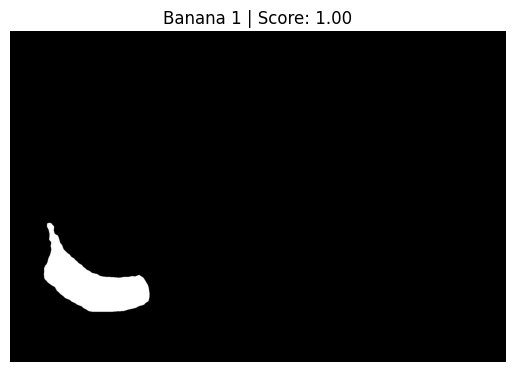

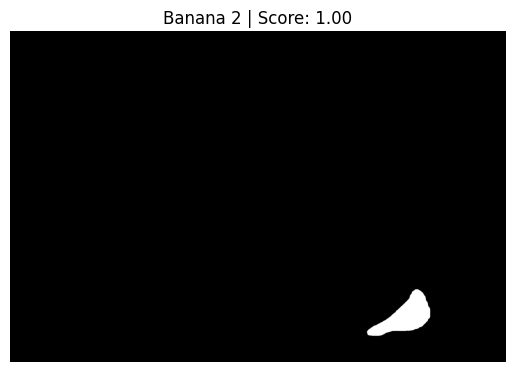

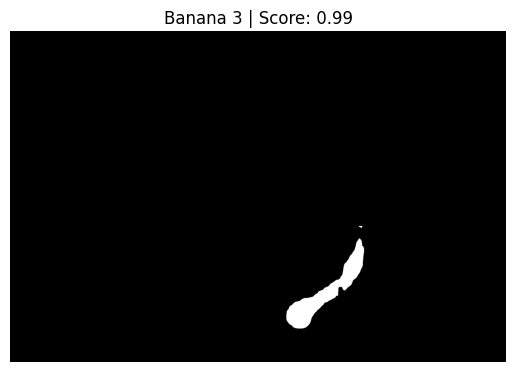

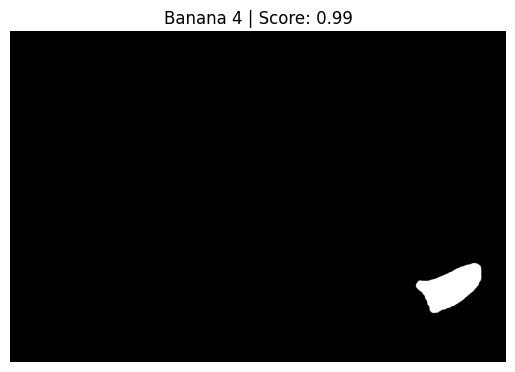

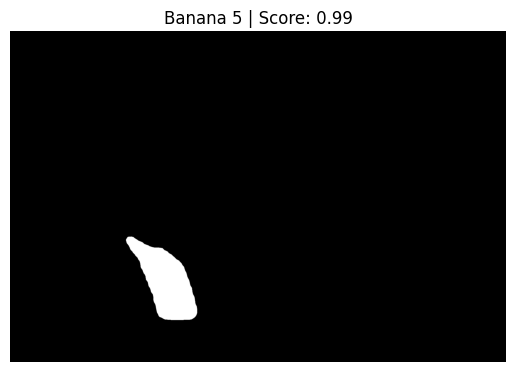

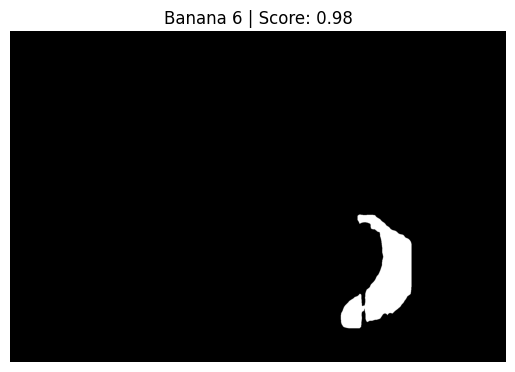

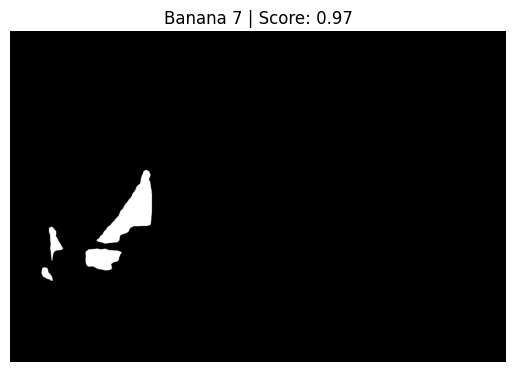

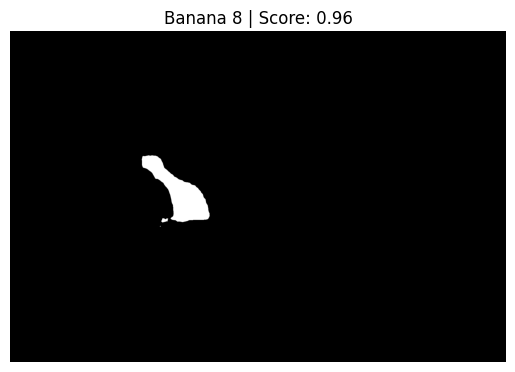

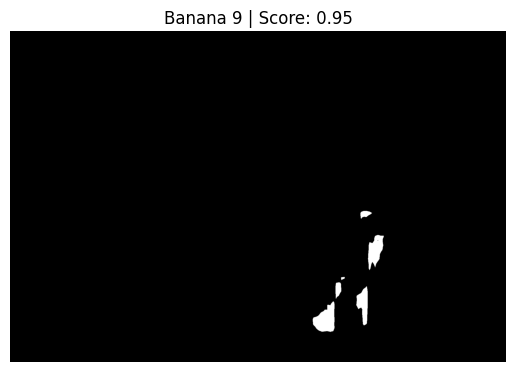

In [ ]:
import matplotlib.pyplot as plt

for i, (mask, score) in enumerate(zip(banana_masks, banana_scores)):
    binary_mask = (mask[0] > 0.5).cpu().numpy()

    plt.imshow(binary_mask, cmap='gray')
    plt.title(f"Banana {i+1} | Score: {score:.2f}")
    plt.axis("off")
    plt.show()

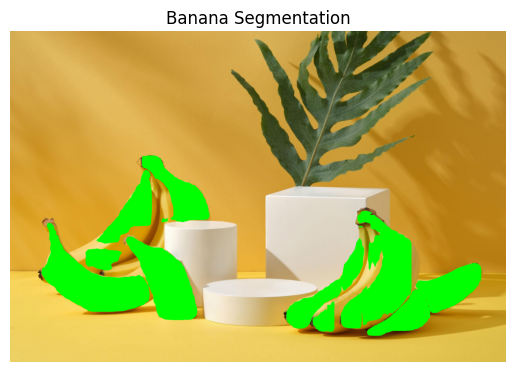

In [ ]:
import numpy as np

overlay = image.copy()

for mask in banana_masks:
    binary_mask = (mask[0] > 0.5).cpu().numpy()
    overlay[binary_mask] = [0, 255, 0]  # green mask

plt.imshow(overlay)
plt.title("Banana Segmentation")
plt.axis("off")
plt.show()

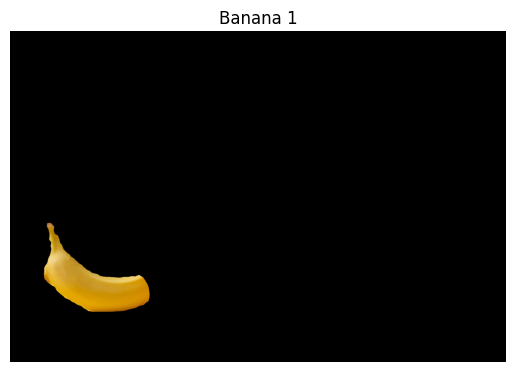

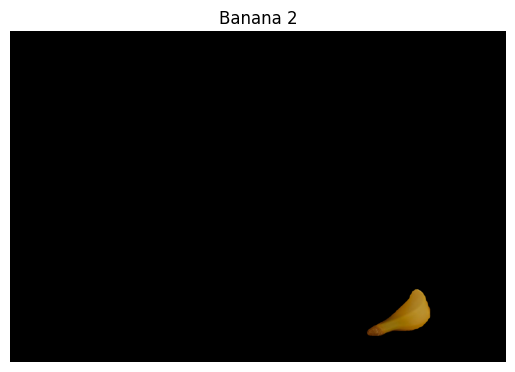

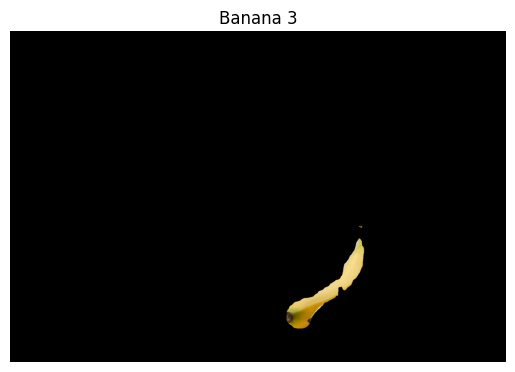

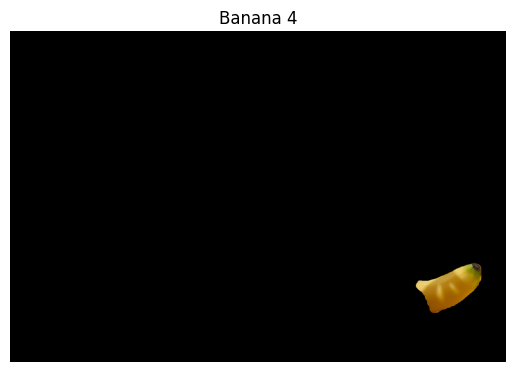

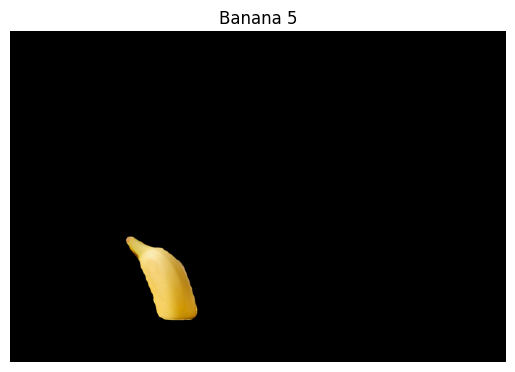

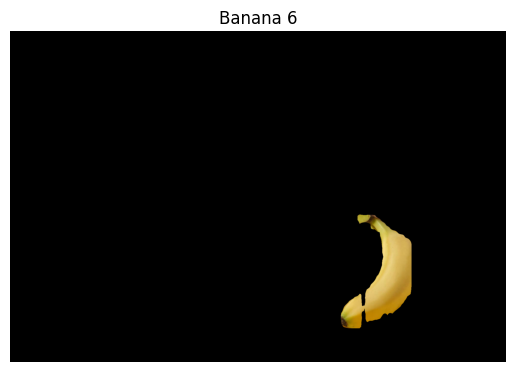

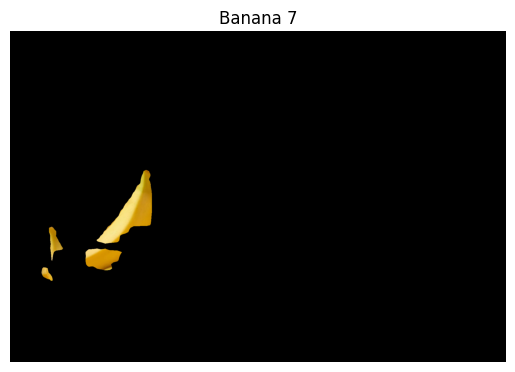

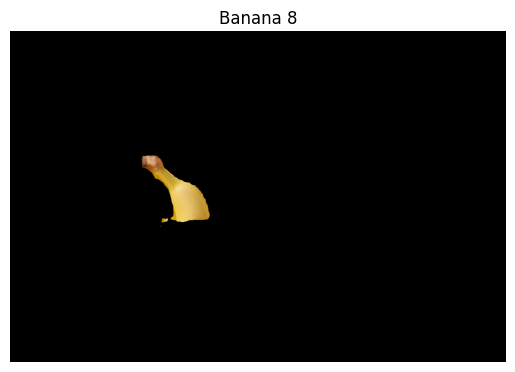

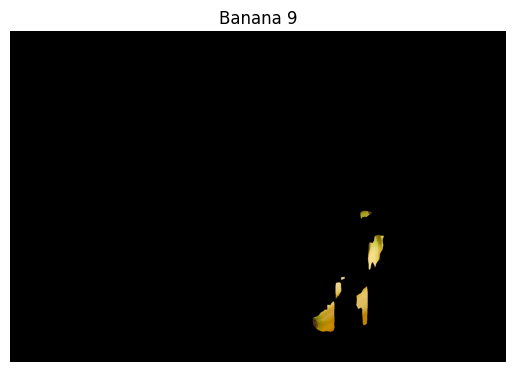

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

separated_bananas = []

for i, mask in enumerate(banana_masks):
    # Convert mask to binary
    binary_mask = (mask[0] > 0.5).cpu().numpy()

    # Create empty image
    isolated = np.zeros_like(image)

    # Apply mask
    isolated[binary_mask] = image[binary_mask]

    separated_bananas.append(isolated)

    # Show result
    plt.imshow(isolated)
    plt.title(f"Banana {i+1}")
    plt.axis("off")
    plt.show()